# Figure 4 — scNanoSeq per-cell SBS1 mutation burden

Power-corrected, diploid-scaled SBS1 somatic mutation burden per single cell across scNanoSeq breast tumour samples, comparing non-tumour cells, the tumour trunk (bulk-informed MRCA), and tumour-all (including private) burdens.

**Panels**
- **a** — per-cell SBS1 burden by sample and cell class (non-tumour / trunk / tumour-all).
- **c** — tumour-all vs non-tumour SBS1 burden (per-sample medians, IQR bars).
- **d** — MRCA (trunk) vs non-tumour SBS1 burden.
- **e** — tumour-all vs MRCA (trunk) SBS1 burden.
- **Supp** — estimated power to detect mutations per cell (all vs truncal).

All inputs live in `data/Fig4_scNanoSeqSBS1/intermediate/`.

## Inputs, outputs, and paths

In [1]:
# --- Nature figure style: thin (0.25) spines/ticks, no top/right spines, embedded fonts ---
import pandas as pd
import numpy as np
import glob
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42, "font.family": "sans-serif", "font.size": 8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.25,
    "xtick.major.width": 0.25, "ytick.major.width": 0.25,
    "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 6, "legend.title_fontsize": 6,
})

def nature_axes(ax, keep_top=False):
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(keep_top)
    for sp in ax.spines.values():
        sp.set_linewidth(0.25)
    ax.tick_params(width=0.25)
    return ax

pd.set_option("display.max_columns", None)

In [2]:
genome_size_mb = 2800

In [3]:
# inputs
# metadata

# metadata: for translating between different sample name conventions, eg BTE1 vs BT36
metadata_fn = 'data/Fig4_scNanoSeqSBS1/intermediate/sample_ID_mapping_dg_annot_tumor_cells.txt'
# annotated_cell_list: used to create a normal cell list, tumor cell list and remnant cells
annotated_cell_list_fn = 'data/Fig4_scNanoSeqSBS1/intermediate/scNanoSeq_metadata_v5.csv'
# total number of detected mutations per sample
mut_count_fn = 'data/Fig4_scNanoSeqSBS1/intermediate/mutation_counts_per_cell.csv'


# mutation data
 # all_data: power corrected mutational burden per cell
cell_burden_folder = 'data/Fig4_scNanoSeqSBS1/intermediate/scNanoSeq_gnomAD_PowerCorrectedMutBurdens/'
# trunk_data_bulk: power corrected mutational burdens per cell, only including mutations that overlap with the bulk deep WGS
cell_bulk_trunk_burden_folder = 'data/Fig4_scNanoSeqSBS1/intermediate/scNanoSeq_TRUNK_Ultradeep_v2_power_corrected_burdens/'

# coverage in matched 
# bulkcov_stats: evaluating the proportion of mutations that are not included, per cell, because the coverage of matched normal sample is too low. This varies from sample to sample
BULKCOV_stats_fn = 'data/Fig4_scNanoSeqSBS1/intermediate/BULKCOV_stats_per_cell.csv'
# cell_clonal_cnv_footprint: total footprint of CNV regions, stratified by total copy number
cell_cnv_footprint = 'data/Fig4_scNanoSeqSBS1/intermediate/cellCnvClonalList_v2.csv'

# signatures
# all mutations per cell
new_sc_exp_fn = 'data/Fig4_scNanoSeqSBS1/intermediate/sig_exposures/scNanoSeq_perCell_BasicSigsSet_Feb25_v3.csv'
# clonal exposures (bulk-defined): CURRENT
new_clonal_exp_fn = 'data/Fig4_scNanoSeqSBS1/intermediate/sig_exposures/H_trunk_Ultradeep_ClonalThresh.csv'
# normal cells merged exposures
normal_merged_exp_fn = 'data/Fig4_scNanoSeqSBS1/intermediate/sig_exposures/H_Grouped_Normal_Cells_v4.csv'

In [4]:
# outputs
# (per-cell burdens + signatures are published as Sup. Table 5, sheet S3.scNanoseq)

In [5]:
# plots
figure5a_fn='../output/Fig4_scNanoSeqSBS1/Fig4a_SBS1_burden_per_cell.pdf'
figure5b_fn='../output/Fig4_scNanoSeqSBS1/Fig4c_tumor_vs_nontumor_SBS1.pdf'
figure5c='../output/Fig4_scNanoSeqSBS1/Fig4e_tumor_vs_MRCA_SBS1.pdf'
figure5d='../output/Fig4_scNanoSeqSBS1/Fig4d_MRCA_vs_nontumor_SBS1.pdf'
power_fig_fn='../output/Fig4_scNanoSeqSBS1/SuppFig_power_to_detect_mutations.pdf'

## Build the per-cell burden and signature tables

In [6]:
# sample_name metadata
metadata = pd.read_csv(metadata_fn, sep=',')
metadata = metadata[['Sample_ID_internal', 'Sample_ID_ms', 'Truncal.node', 'no_tumor_cells', 'tumor_cells']]
cancer_cells = []
for index, row in metadata.iterrows():
    cancer_cells = cancer_cells + row['tumor_cells'].split(';')
snames_df=metadata.loc[:,['Sample_ID_internal', 'Sample_ID_ms']].copy()
sample_id_dict = snames_df.set_index('Sample_ID_internal')['Sample_ID_ms'].to_dict()

annotated_cell_list = pd.read_csv(annotated_cell_list_fn)
normal_curated_cells = []
for index, row in annotated_cell_list.iterrows():
    if pd.notna(row['non_tumor_cells_curated_standardized']):
        normal_curated_cells += row['non_tumor_cells_curated_standardized'].split(',')
transformed_cancer_cells = []
for index, row in annotated_cell_list.iterrows():
    transformed_cancer_cells  += row['tumor_cells'].split(',')

remnant_cells = []
for index, row in annotated_cell_list.iterrows():
    if not pd.isna(row['remnant_cells']):
        remnant_cells += str(row['remnant_cells']).split(',')

normal_curated_cells = [sample_id_dict[cell.split('_')[0]] + '_' + cell.split('_')[1] for cell in normal_curated_cells]
transformed_cancer_cells = [sample_id_dict[cell.split('_')[0]] + '_' + cell.split('_')[1] for cell in transformed_cancer_cells]
remnant_cells = [sample_id_dict[cell.split('_')[0]] + '_' + cell.split('_')[1] for cell in remnant_cells]


In [7]:
def compileCellBurdens(resultPath):
    """
    Compile cell burden statistics and save results.

    Parameters:
        resultPath (str): Path to the directory where output files will be retrieved from

    Returns:
        all_data: a data frame will have #cells x #copy number states (1..5) rows
            mut_burden_per_multiplicity: corrected mutation burden, split per multiplicity
            analytical_power_g: analytical power to detect mutations, calculated per multiplicity
            mut_count: detected mutation count
            power_burden_product_sum: corrected mutation burden times power: should be the detected mutation count (or close)
    """
    
    # there are folders CN1, CN2, through CN5
    file_paths = glob.glob(resultPath + 'CN*_regions_corr_power_output/*_power_corrected_results.csv')

    # Add file path as a new column in each dataframe
    
    # Load all tables into a list of dataframes
    # there will be a data frame for CN1, CN2, ..., CN5
    dataframes = [pd.read_csv(file) for file in file_paths]
    
    for i, df in enumerate(dataframes):
        df['file_path'] = file_paths[i]
        
    # concatenate all dataframes into a single dataframe, combining all results per cell
    all_data = pd.concat(dataframes, ignore_index=True)
    all_data['CN'] = all_data['file_path'].str.extract(r'CN(\d+)_')
    all_data['sample_name'] = all_data['cell_name'].str.extract(r'([^_]+)_')

    # extract corrected mutational burden per multiplicity as columns
    mut_burden_df = all_data['mut_burden_per_multiplicity'].apply(lambda x: pd.Series([int(i) for i in x.strip('[]').split()]))
    # Rename the new columns
    mut_burden_df.columns = [f'mut_burden_{i+1}' for i in mut_burden_df.columns]

    # extract mutation detection power, per multiplicity
    power_df = all_data['analytical_power_g'].apply(lambda x: pd.Series([float(i) for i in x.strip('[ ]').split()]))
    # Rename the new columns
    power_df.columns = [f'power_df_{i+1}' for i in power_df.columns]

    # extract numbers of detected mutations as columns, per multiplicity
    mut_count_df = pd.Series(all_data['mut_count'].apply(lambda x: pd.Series([int(i) for i in x.strip('[]').split(',')])).sum(axis=1))
    mut_count_df.name='detected_muts'

    # corrected mutation burden times power: should be the detected mutation count (or close)    
    power_burden = pd.Series((mut_burden_df * power_df.values).sum(axis=1))
    power_burden.name = 'power_burden_product_sum'

    # Concatenate the new columns with the original dataframe
    all_data = pd.concat([all_data, mut_burden_df, mut_count_df, power_burden], axis=1)
    # total corrected mutation burden per cell x (total copy number) 
    all_data['total_burden'] = mut_burden_df.sum(axis=1, skipna=True)

    # rows in this data frame correspond to cell/CN 

    return all_data

In [8]:
all_data = compileCellBurdens(cell_burden_folder)
# calculate cell G
# this table contains the following columns: cellID	cnv	footprint_bp	sample
cell_clonal_cnv_footprint = pd.read_csv(cell_cnv_footprint, index_col=0)
# ploidy across all cells
all_data['CN'] = all_data['CN'].astype(float)
all_data = pd.merge(all_data, cell_clonal_cnv_footprint, left_on=['cell_name', 'CN'], right_on=['cellID', 'cnv'], how='left' )
# rows are cells/copy number states

trunk_data_bulk = compileCellBurdens(cell_bulk_trunk_burden_folder)


In [9]:
mut_count_df = pd.read_csv(mut_count_fn).iloc[:,[0,2]]
mut_count_df.columns = ['cell_name', 'raw_mutation_count']
mut_count_df.head(1)

,cell_name,raw_mutation_count
0,BTE1_sc001,161


In [10]:
# calculate cell-counted ploidy
cell_ploidy = (
    all_data
    .groupby('cell_name')
    .apply(lambda group: (group['CN'] * group['length_in_CN[Mb]']).sum() / group['length_in_CN[Mb]'].sum())
    .reset_index(name='weighted_avg_CN')
)

cell_ploidy['sample'] = cell_ploidy['cell_name'].str[:4]
cell_ploidy['isTumor'] = cell_ploidy['cell_name'].isin(transformed_cancer_cells)
sample_ploidy = cell_ploidy[cell_ploidy['isTumor']==True].groupby('sample').agg({'weighted_avg_CN': 'median'}).reset_index()
cell_ploidy.head(1)


/tmp/ipykernel_562001/2855652749.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: (group['CN'] * group['length_in_CN[Mb]']).sum() / group['length_in_CN[Mb]'].sum())


,cell_name,weighted_avg_CN,sample,isTumor
0,BTE1_sc001,3.43353,BTE1,True


In [11]:

# the rows correspond to cell x (total copy number)
all_data['mult_sum'] = (all_data['mut_burden_1'].fillna(0)  + all_data['mut_burden_2'].fillna(0) * 2 + all_data['mut_burden_3'].fillna(0) * 3 + all_data['mut_burden_4'].fillna(0) * 4)
all_data['m_over_T_sum'] = all_data['mult_sum'] / all_data['CN']


# these are estimates of trunk mutation burden where bulk WGS data is available
trunk_data_bulk['mult_sum_trunk_bulk'] = (trunk_data_bulk['mut_burden_1'].fillna(0)  + trunk_data_bulk['mut_burden_2'].fillna(0) * 2 + trunk_data_bulk['mut_burden_3'].fillna(0) * 3 + trunk_data_bulk['mut_burden_4'].fillna(0) * 4)
trunk_data_bulk['m_over_T_sum_trunk_bulk'] = trunk_data_bulk['mult_sum_trunk_bulk'] / trunk_data_bulk['CN'].astype(float)

# make a per cell summary (aggregating mutations across copy number states)
# aggreggate data to per cell statistics
# all mutations detected in a cell
aggregated_all_data = all_data.groupby('cell_name').agg({'m_over_T_sum': 'sum', 
                                                         'length_in_CN[Mb]' : 'sum',
                                                         'total_burden': 'sum',
                                                         'mult_sum': 'sum',
                                                         'footprint_bp' : 'sum',
                                                         'detected_muts' : 'sum',
                                                         'power_burden_product_sum' : 'sum'}).reset_index()

# only the mutations that were also detected in the trunk
aggregated_cell_trunk_bulk_burden = trunk_data_bulk.groupby('cell_name').agg({
                                                             'total_burden': 'sum',
                                                             'mult_sum_trunk_bulk': 'sum',
                                                             'm_over_T_sum_trunk_bulk' : 'sum',
                                                             'detected_muts' : 'sum',
                                                            'power_burden_product_sum' : 'sum'
                                                             }).reset_index()
aggregated_cell_trunk_bulk_burden.columns = ['cell_name','trunk_bulk_total_burden', 'mult_sum_trunk_bulk', 'm_over_T_sum_trunk_bulk', 'detected_muts_trunk_bulk', 'power_burden_product_sum_trunk_bulk']

# rows in this data frame correspond to cells
merged_cell_data = aggregated_all_data
merged_cell_data = pd.merge(merged_cell_data, aggregated_cell_trunk_bulk_burden, how='left')
merged_cell_data = pd.merge(merged_cell_data, mut_count_df,  how='left') # there is a problem here for BTE3
merged_cell_data = pd.merge(merged_cell_data, cell_ploidy[['cell_name','weighted_avg_CN']], how='left')

# effective genome size, calculated from all mutations after power correction
merged_cell_data['G'] = merged_cell_data['total_burden'] / merged_cell_data['m_over_T_sum'] 
# averge multiplicity
merged_cell_data['mult_avg']= merged_cell_data['mult_sum']/merged_cell_data['total_burden'] 
# averge multiplicity for truncal mutations (where available)
merged_cell_data['mult_avg_trunk_bulk']= merged_cell_data['mult_sum_trunk_bulk']/merged_cell_data['trunk_bulk_total_burden'] 
# burden corrected by effective genome size and footprint of the genome with with total copy number of 1 to 5
merged_cell_data['burden_diploid'] = 2 * merged_cell_data['m_over_T_sum'] * genome_size_mb / merged_cell_data['length_in_CN[Mb]']
# equivalent for the trunk
merged_cell_data['burden_trunk_bulk_diploid'] = 2 *merged_cell_data['m_over_T_sum_trunk_bulk'] * genome_size_mb / (merged_cell_data['footprint_bp']/1e6)

# the logic is that if a cell is in the transformed_list, it will be considered a tumor cell, and normal otherwise
merged_cell_data['isTumor'] = merged_cell_data['cell_name'].isin(transformed_cancer_cells)
merged_cell_data['sample_id'] = merged_cell_data['cell_name'].str.split('_').str[0]
# sample_id x T (Tumor) or N (Normal)
merged_cell_data['sample_id_TN'] = merged_cell_data['sample_id'] + '_' + merged_cell_data['isTumor'].map({True: 'T', False : 'N'})

# data on putatively somatic mutations filtered out because sequencing coverage in matched normal sample is less than 20
bulkcov_stats = pd.read_csv(BULKCOV_stats_fn)

aggregated_cell_footprint = all_data.groupby('cell_name').agg({'length_in_CN[Mb]': 'sum'}).reset_index()
merged_cell_data = pd.merge(merged_cell_data, aggregated_cell_footprint)
merged_cell_data = pd.merge(merged_cell_data, bulkcov_stats, left_on = 'cell_name', right_on='cell', how='left')


# correct by percentage of discarded mutations (because of germline coverage) and total copy number
# this is the column that has the total mutational burden

# correct the diploid estimate of burden by coverage in matched normal sample
merged_cell_data['burden_diploid_corr'] = merged_cell_data['burden_diploid'] * (1 / (1-merged_cell_data['perc_of_disc_muts']))
# bulk equivalent
merged_cell_data['burden_trunk_bulk_diploid_corr'] = merged_cell_data['burden_trunk_bulk_diploid'] * (1 / (1-merged_cell_data['perc_of_disc_muts']))
# trunk equivalent
merged_cell_data['trunk_bulk_total_burden_corr'] =  merged_cell_data['trunk_bulk_total_burden'] *  (1 / (1-merged_cell_data['perc_of_disc_muts'])) * 3000 / (merged_cell_data['footprint_bp']/1e6) 


# total_burden_corr, trunk_bulk_total_burden_corr, total_burden_corr_G can be removed
# total burden corrected by germline coverage and percentage of gnome where total copy number is in 1..5, not corrected by effective genome size (ie not diploid)
merged_cell_data['total_burden_corr'] =  merged_cell_data['total_burden'] *  (1 / (1-merged_cell_data['perc_of_disc_muts'])) * 3000 / merged_cell_data['length_in_CN[Mb]'] 
# rescale to diploid genome
merged_cell_data['total_burden_corr_G'] =  merged_cell_data['total_burden'] *  (1 / (1-merged_cell_data['perc_of_disc_muts'])) * 2 * 3000 / merged_cell_data['length_in_CN[Mb]'] / merged_cell_data['G']

# recovering the average power to detect mutations per cell
merged_cell_data['cell_power_exp'] = merged_cell_data['power_burden_product_sum'] / merged_cell_data['total_burden']
merged_cell_data['trunk_bulk_power_exp'] = merged_cell_data['power_burden_product_sum_trunk_bulk'] / merged_cell_data['trunk_bulk_total_burden']

In [12]:
# per cell truncal (bulk) exposures
# the phylogenetic-defined truncal mutations are not used

cell_trunk_df = merged_cell_data[merged_cell_data['isTumor']==True][['cell_name','sample_id','burden_trunk_bulk_diploid_corr']].copy()
cell_trunk_df.columns = ['cell_name', 'sample_id','burden_diploid_corr']
cell_trunk_df['data_type'] = 'trunk_cell'
cell_trunk_df['cell_name'] = cell_trunk_df['cell_name'] + '_trunk'
cell_trunk_df.index = cell_trunk_df['cell_name']


In [13]:
# these are dummies - to merge SBS1 exposures
merged_normal_cells = pd.DataFrame({'sample_id' : snames_df['Sample_ID_ms']})
merged_normal_cells['data_type'] = 'normal_merged'
merged_normal_cells['cell_name'] = merged_normal_cells['sample_id'] + '_normal_merged'
merged_normal_cells.index = merged_normal_cells['cell_name']
merged_normal_cells.head()

,sample_id,data_type,cell_name
cell_name,,,
BTE1_normal_merged,BTE1,normal_merged,BTE1_normal_merged
BTE2_normal_merged,BTE2,normal_merged,BTE2_normal_merged
BTE3_normal_merged,BTE3,normal_merged,BTE3_normal_merged
BTE4_normal_merged,BTE4,normal_merged,BTE4_normal_merged
BTE5_normal_merged,BTE5,normal_merged,BTE5_normal_merged


In [14]:
# add per cell data to trunk data

merged_cell_data['data_type'] = merged_cell_data['isTumor'].map({True: 'scTumor', False: 'scNormal'})
merged_cell_data.loc[merged_cell_data['cell_name'].isin(remnant_cells), 'data_type'] = 'other'

# add the trunk data to the cell-level data
merged_cell_data2 = pd.concat([merged_cell_data, 
                               cell_trunk_df,
                               merged_normal_cells], axis=0)

# Change the order of data_type
custom_order = ['scNormal', 'normal_merged','trunk_tree', 'trunk_cell', 'scTumor', 'other']

merged_cell_data2['data_type'] = pd.Categorical(
    merged_cell_data2['data_type'], 
    categories=custom_order, 
    ordered=True
)
merged_cell_data2.head(1)

,cell_name,m_over_T_sum,length_in_CN[Mb],total_burden,mult_sum,footprint_bp,detected_muts,power_burden_product_sum,trunk_bulk_total_burden,mult_sum_trunk_bulk,m_over_T_sum_trunk_bulk,detected_muts_trunk_bulk,power_burden_product_sum_trunk_bulk,raw_mutation_count,weighted_avg_CN,G,mult_avg,mult_avg_trunk_bulk,burden_diploid,burden_trunk_bulk_diploid,isTumor,sample_id,sample_id_TN,cell,no_total_unf_mutations,no_discarded_mutations_BULKCOV20,perc_of_disc_muts,burden_diploid_corr,burden_trunk_bulk_diploid_corr,trunk_bulk_total_burden_corr,total_burden_corr,total_burden_corr_G,cell_power_exp,trunk_bulk_power_exp,data_type
0,BTE1_sc001,2284.75,2807.553722,6354.0,7946.0,1.539041e+09,132.0,131.979528,2383.0,3094.0,902.25,51.0,50.988761,161.0,3.43353,2.781048,1.250551,1.298363,4557.205762,3282.953316,True,BTE1,BTE1_T,BTE1_sc001,187.0,11.0,0.058824,4842.031122,3488.137898,4935.418959,7213.886894,5187.890488,0.020771,0.021397,scTumor


In [15]:
# signatures: clonal mutations per sample
new_trunk_exp_df = pd.read_csv(new_clonal_exp_fn, index_col=0)
new_trunk_exp_df.index.name = 'signature'

truncal_exposures_per_sample_norm_T = new_trunk_exp_df.div(new_trunk_exp_df.sum(axis=0), axis=1).T
truncal_exposures_per_sample_norm_T.index = truncal_exposures_per_sample_norm_T.index.str.replace('_tunk', '_trunk')
truncal_exposures_per_sample_norm_T['data_type'] = 'sample_trunk'
truncal_exposures_per_sample_norm_T['sample_id'] = truncal_exposures_per_sample_norm_T.index.str.split('_trunk').str[0]
truncal_exposures_per_sample_norm_T.head(10)

# for each "trunk" tumor cell, look up SBS1 exposure of the trunk
cell_trunk_df = cell_trunk_df.loc[cell_trunk_df['sample_id'].isin(new_trunk_exp_df.columns),]
cell_trunk_sigs = truncal_exposures_per_sample_norm_T.loc[cell_trunk_df['sample_id'],][['SBS1', 'SBS3']]
cell_trunk_sigs.index= cell_trunk_df.index

In [16]:
# signatures: 
# all mutations per cell
new_sc_exp_df = pd.read_csv(new_sc_exp_fn, index_col=0)
new_sc_exp_df.index.name = 'signature'

# Normalize all_exposure_data by dividing by column sum
normalized_exposure_data = new_sc_exp_df.div(new_sc_exp_df.sum(axis=0), axis=1)
normalized_exposure_data_T = normalized_exposure_data.T
normalized_exposure_data_T['sample_id'] = normalized_exposure_data_T.index.str.replace('_.*', '')
normalized_exposure_data_T['data_type'] = 'sc_total'
normalized_exposure_data_T.head(1)

normal_merged_exp_df = pd.read_csv(normal_merged_exp_fn, index_col=0).T
normal_merged_exp_df = normal_merged_exp_df.div(normal_merged_exp_df.sum(axis=1), axis=0)
normal_merged_exp_df.index = normal_merged_exp_df.index + '_normal_merged'
normal_merged_exp_df.index.name = ''

normalized_exposure_data_T_with_trunk = pd.concat([normalized_exposure_data_T,  truncal_exposures_per_sample_norm_T, cell_trunk_sigs, normal_merged_exp_df], axis=0)

merged_cell_data2['cell_name_std'] = merged_cell_data2['cell_name'].str.replace(
    r'_sc(\d+)',
    lambda m: f"_sc{int(m.group(1)):03d}",
    regex=True
)

merged_cell_data2_sigs = pd.merge(merged_cell_data2, normalized_exposure_data_T_with_trunk, left_on='cell_name_std', right_index=True, how='left')


normal_merged_exp_df['sample_id'] = [s[:4] for s in normal_merged_exp_df.index]
# this column will use the 'merged_normal' exposures for the normal cells
merged_cell_data2_sigs['SBS1_merged_normal'] = merged_cell_data2_sigs['sample_id_x'].map(normal_merged_exp_df.set_index('sample_id')['SBS1'])
# for tumor cells or trunk, keep the per cell SBS1 exposures
# normal cells will use SBS1_merged_normal and not be overwritten
rows_to_leave = (merged_cell_data2_sigs['isTumor']==True) | (merged_cell_data2_sigs['cell_name'].str.contains('_trunk'))  | (merged_cell_data2_sigs['cell_name'].str.contains('_normal_merged'))
merged_cell_data2_sigs.loc[rows_to_leave, 'SBS1_merged_normal'] = merged_cell_data2_sigs.loc[rows_to_leave,'SBS1']


merged_cell_data2_sigs['total_burden_SBS1'] = merged_cell_data2_sigs['total_burden_corr'] * merged_cell_data2_sigs['SBS1']
merged_cell_data2_sigs['total_burden_SBS3'] = merged_cell_data2_sigs['total_burden_corr'] * merged_cell_data2_sigs['SBS3']
merged_cell_data2_sigs['burden_diploid_corr_SBS1'] = merged_cell_data2_sigs['burden_diploid_corr'] * merged_cell_data2_sigs['SBS1']
merged_cell_data2_sigs['burden_diploid_corr_SBS1_merged_normal'] = merged_cell_data2_sigs['burden_diploid_corr'] * merged_cell_data2_sigs['SBS1_merged_normal']


## Supp — power to detect mutations per cell (all vs truncal)

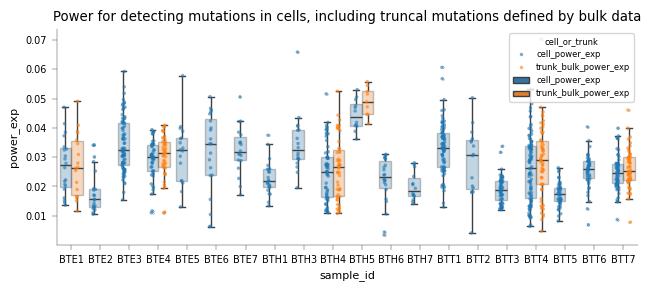

In [17]:
#merged_cell_data[['sample_id', 'power_burden_product_sum', 'total_burden', 'cell_power_exp', 'trunk_bulk_power_exp', 'mult_avg', 'mult_avg_trunk_bulk']]
plt.figure(figsize=(7.5, 2.8))  # Width x Height in inches

# Melt the dataframe to long format
melted_data = merged_cell_data.melt(id_vars=['sample_id'], value_vars=['cell_power_exp', 'trunk_bulk_power_exp'], 
                                    var_name='cell_or_trunk', value_name='power_exp')


# Create the stripplot
sns.stripplot(
    x='sample_id',
    y='power_exp',
    hue='cell_or_trunk',
    data=melted_data,
    jitter=True,
    dodge=True,
    alpha=0.6,
    size=2.5
)



# Overlay the boxplot with transparency
boxplot = sns.boxplot(
    x='sample_id',
    y='power_exp',
    hue='cell_or_trunk',
    data=melted_data,
    width=0.8,
    fliersize=1.2,
    flierprops=dict(markersize=1.2, markeredgewidth=0.2)
)

# Set transparency (alpha) for the boxes
for patch in boxplot.patches:
    patch.set_alpha(0.3)  # Adjust transparency here

plt.title('Power for detecting mutations in cells, including truncal mutations defined by bulk data')


for _ax in plt.gcf().axes:
    nature_axes(_ax)
plt.savefig(
    power_fig_fn,
    format='pdf',
    dpi=300,                # High resolution
    bbox_inches='tight',    # Trim whitespace
    metadata={'Creator': 'Matplotlib'}  # Metadata for Illustrator
)
plt.show()


## a — per-cell SBS1 burden by sample and cell class

/tmp/ipykernel_562001/2338471398.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = merged_cell_data2_sigs_sel.groupby(['sample_id_x', 'data_type_x'])[['burden_diploid_corr_SBS1_merged_normal']].median().reset_index()


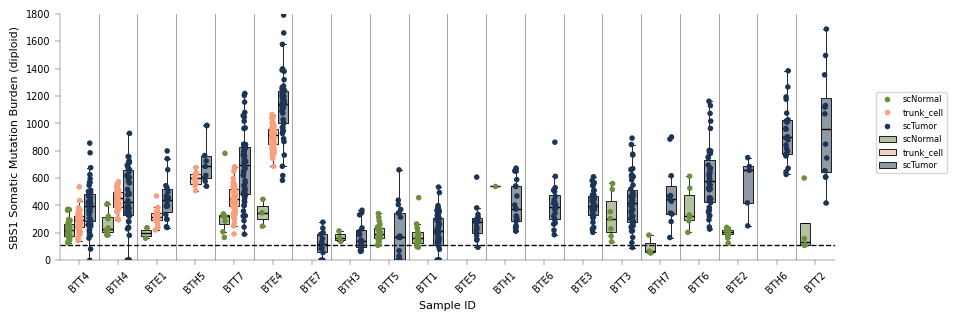

In [18]:
# the approach to signatures in normal cells is different


sel_cells = transformed_cancer_cells + normal_curated_cells
sel_cells2 = sel_cells + [c + '_trunk' for c in sel_cells]
merged_cell_data2_sigs_sel = merged_cell_data2_sigs[merged_cell_data2_sigs['cell_name'].isin(sel_cells2)].copy()
# Remove absent categories in data_type_x column
merged_cell_data2_sigs_sel['data_type_x'] = merged_cell_data2_sigs_sel['data_type_x'].cat.remove_unused_categories()
merged_cell_data2_sigs_sel = merged_cell_data2_sigs_sel[merged_cell_data2_sigs_sel['data_type_x'].isin(['scTumor', 'scNormal', 'trunk_cell'])]



custom_order = ['BTT4', 'BTH4','BTE1', 'BTH5',  'BTT7', 'BTE4'] 


df_grouped = merged_cell_data2_sigs_sel.groupby(['sample_id_x', 'data_type_x'])[['burden_diploid_corr_SBS1_merged_normal']].median().reset_index()

# Pivot the table to wide format
df_wide = df_grouped.pivot(index='sample_id_x', columns='data_type_x', values='burden_diploid_corr_SBS1_merged_normal')

# Reset index to make `sample_id_x` a column again
df_wide.reset_index(inplace=True)

df_wide['tumor_normal_diff'] = df_wide['scTumor'] - df_wide['scNormal']
df_wide['tumor_normal_diff'] = df_wide['tumor_normal_diff'].fillna(0)

# Sort by 'tumor_normal_diff' in ascending order
df_wide = df_wide.sort_values(by='scTumor', ascending=True)

custom_order = custom_order + [c for c in df_wide['sample_id_x'] if c not in custom_order] 

merged_cell_data2_sigs_sel['sample_id_x'] = pd.Categorical(merged_cell_data2_sigs_sel['sample_id_x'], 
                                                           categories=custom_order, ordered=True)
plt.figure(figsize=(10, 3.2))

# Set font to Arial for Illustrator compatibility
#matplotlib.rcParams['font.family'] = 'Arial'

# Define a color palette for the levels of data_type_x
palette = {
    'scTumor': '#1C3557',
    'scNormal': '#6B8F3C',
    'trunk_tree': 'green',
    'trunk_cell': '#F89F7B',
    'normal_merged': 'orange',
    'other': 'gray'
}

# Create the stripplot
sns.stripplot(
    x='sample_id_x',
    y='burden_diploid_corr_SBS1_merged_normal',
    hue='data_type_x',  # Conditional column
    data=merged_cell_data2_sigs_sel,
    jitter=True,
    dodge=True,  # Set dodge to True for alignment
    alpha=1,
    size=4,  # Increase the size of the points
    palette=palette  # Assign the color palette
)

# Overlay the boxplot with transparency
boxplot = sns.boxplot(
    x='sample_id_x',
    y='burden_diploid_corr_SBS1_merged_normal',
    hue='data_type_x',  # Conditional column
    data=merged_cell_data2_sigs_sel,
    width=0.8,
    palette=palette,  # Assign the color palette
    linewidth=1,  # Make the black lines thicker
    showfliers=False,  # Do not show outliers
    boxprops=dict(edgecolor='black', linewidth=0.6),
    whiskerprops=dict(color='black',  linewidth=0.6),
    capprops=dict(color='black',  linewidth=0.6),
    medianprops=dict(color='black'),
    flierprops=dict(markeredgecolor='black', linewidth=0.5)
)

# Remove the legend for the stripplot to avoid duplication
sns.move_legend(boxplot, "upper right")

for patch in boxplot.patches:
    patch.set_facecolor((patch.get_facecolor()[0],  # Retain original color
                         patch.get_facecolor()[1], 
                         patch.get_facecolor()[2], 
                         0.5))  # Set alpha for transparency

# Add vertical dividers
for i in range(1, 20):
    plt.axvline(x=i - 0.5, color='grey', linewidth=0.5)

# Customize the plot
plt.ylim(0, 1800)
plt.xlabel('Sample ID')
plt.ylabel('SBS1 Somatic Mutation Burden (diploid)')
plt.xticks(rotation=45)

# Remove the legend
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 0.7))
#plt.legend().remove()

plt.axhline(y=109, color='k', linestyle='--', linewidth=1)
# Save as PDF with editable text
for _ax in plt.gcf().axes:
    nature_axes(_ax)
plt.savefig(
    figure5a_fn,
    format='pdf',
    dpi=300,                # High resolution
    bbox_inches='tight',    # Trim whitespace
    metadata={'Creator': 'Matplotlib'}  # Metadata for Illustrator
)
plt.show()



In [19]:
summary_table = (
    merged_cell_data2_sigs_sel
    .groupby(['sample_id_x', 'data_type_x'])['burden_diploid_corr_SBS1_merged_normal']
    .agg(
        count = 'count',
        mean_value = 'median',
        Q1 = lambda x: x.quantile(0.25),
        Q3 = lambda x: x.quantile(0.75)
    )
    .reset_index()
)

summary_table['IQR'] = summary_table['Q3'] - summary_table['Q1']

# Reorder columns for clarity
summary_table = summary_table[['sample_id_x', 'data_type_x', 'count', 'mean_value', 'Q1', 'Q3', 'IQR']]

print(summary_table)

# Save to CSV
summary_table.to_csv('../output/Fig4_scNanoSeqSBS1/Fig4a_summary_table.csv', index=False)


   sample_id_x data_type_x  count   mean_value          Q1           Q3  \
0         BTT4    scNormal     31   217.098850  174.134873   267.219797   
1         BTT4  trunk_cell     57   290.589354  240.514704   320.420857   
2         BTT4     scTumor     57   395.513597  288.903714   482.618935   
3         BTH4    scNormal     10   228.905281  209.443909   316.248998   
4         BTH4  trunk_cell     50   456.845771  389.257412   500.777955   
5         BTH4     scTumor     50   421.837721  329.281030   655.851895   
6         BTE1    scNormal      2   198.887441  179.661417   218.113464   
7         BTE1  trunk_cell     18   315.599498  293.979306   344.689872   
8         BTE1     scTumor     18   442.067640  349.370556   520.916366   
9         BTH5    scNormal      0          NaN         NaN          NaN   
10        BTH5  trunk_cell      9   597.814988  559.249687   632.814005   
11        BTH5     scTumor      9   684.981878  601.543507   764.300250   
12        BTT7    scNorma

/tmp/ipykernel_562001/817602405.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['sample_id_x', 'data_type_x'])['burden_diploid_corr_SBS1_merged_normal']


## c — tumour-all vs non-tumour SBS1 burden

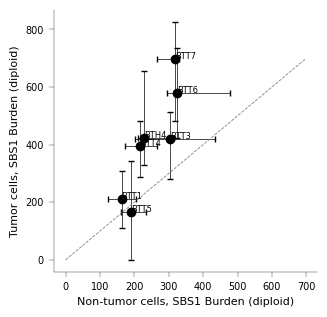

In [20]:
# Assume `summary_table` has been generated as discussed earlier

# Separate normal and tumor rows
normal_df = summary_table[summary_table['data_type_x'] == 'scNormal']
tumor_df = summary_table[summary_table['data_type_x'] == 'scTumor']

# Merge them side-by-side on sample_id_x
plot_df = pd.merge(
    normal_df,
    tumor_df,
    on='sample_id_x',
    suffixes=('_normal', '_tumor')
)

# Keep only rows where both normal and tumor have > 5 data points
plot_df = plot_df[
    (plot_df['count_normal'] > 5) &
    (plot_df['count_tumor'] > 5)
]

# Drop rows where either mean is NaN (in case of missing data)
plot_df = plot_df.dropna(subset=['mean_value_normal', 'mean_value_tumor'])

# Compute asymmetric error bars
xerr = np.array([
    plot_df['mean_value_normal'] - plot_df['Q1_normal'],    # lower error
    plot_df['Q3_normal'] - plot_df['mean_value_normal']     # upper error
])

yerr = np.array([
    plot_df['mean_value_tumor'] - plot_df['Q1_tumor'],      # lower error
    plot_df['Q3_tumor'] - plot_df['mean_value_tumor']       # upper error
])

# Plot
plt.figure(figsize=(3.4, 3.4))  # Width x Height in inches

plt.errorbar(
    x=plot_df['mean_value_normal'],
    y=plot_df['mean_value_tumor'],
    xerr=xerr,
    yerr=yerr,
    fmt='o',
    color='k',
    ecolor='k',
    elinewidth=0.5,
    capsize=2
)

# Add sample labels
for _, row in plot_df.iterrows():
    plt.text(
        row['mean_value_normal'],
        row['mean_value_tumor'],
        row['sample_id_x'],
        fontsize=6
    )

# Add diagonal reference line
max_burden = max(plot_df['mean_value_normal'].max(), plot_df['mean_value_tumor'].max())
plt.plot([0, max_burden], [0, max_burden], color='gray', linestyle='--', linewidth=0.6)

# Axis labels
plt.xlabel('Non-tumor cells, SBS1 Burden (diploid)')
plt.ylabel('Tumor cells, SBS1 Burden (diploid)')

# Save figure
for _ax in plt.gcf().axes:
    nature_axes(_ax)
plt.savefig(
    figure5b_fn,
    format='pdf',
    dpi=300,
    bbox_inches='tight',
    metadata={'Creator': 'Matplotlib'}
)
plt.show()



## e — tumour-all vs MRCA (trunk) SBS1 burden

/tmp/ipykernel_562001/1229983193.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['sample_id_x', 'data_type_x'])['burden_diploid_corr_SBS1_merged_normal']


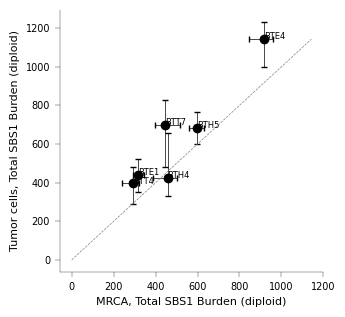

In [21]:
# Compute summary table for tumor and trunk
summary_table_tt = (
    merged_cell_data2_sigs_sel
    .groupby(['sample_id_x', 'data_type_x'])['burden_diploid_corr_SBS1_merged_normal']
    .agg(
        count = 'count',
        mean_value = 'median',
        Q1 = lambda x: x.quantile(0.25),
        Q3 = lambda x: x.quantile(0.75)
    )
    .reset_index()
)

summary_table_tt['IQR'] = summary_table_tt['Q3'] - summary_table_tt['Q1']


# Separate trunk and tumor
trunk_df = summary_table_tt[summary_table_tt['data_type_x'] == 'trunk_cell']
tumor_df = summary_table_tt[summary_table_tt['data_type_x'] == 'scTumor']

# Merge side-by-side
plot_df_tt = pd.merge(
    trunk_df,
    tumor_df,
    on='sample_id_x',
    suffixes=('_trunk', '_tumor')
)

# Filter to only include rows where both have count > 5
plot_df_tt = plot_df_tt[
    (plot_df_tt['count_trunk'] > 5) &
    (plot_df_tt['count_tumor'] > 5)
]

# Drop rows with missing mean values
plot_df_tt = plot_df_tt.dropna(subset=['mean_value_trunk', 'mean_value_tumor'])

# Compute asymmetric error bars
xerr_tt = np.array([
    plot_df_tt['mean_value_trunk'] - plot_df_tt['Q1_trunk'],   # lower
    plot_df_tt['Q3_trunk'] - plot_df_tt['mean_value_trunk']    # upper
])

yerr_tt = np.array([
    plot_df_tt['mean_value_tumor'] - plot_df_tt['Q1_tumor'],   # lower
    plot_df_tt['Q3_tumor'] - plot_df_tt['mean_value_tumor']    # upper
])

# Plot
plt.figure(figsize=(3.4, 3.4))

plt.errorbar(
    x=plot_df_tt['mean_value_trunk'],
    y=plot_df_tt['mean_value_tumor'],
    xerr=xerr_tt,
    yerr=yerr_tt,
    fmt='o',
    color='k',
    ecolor='k',
    elinewidth=0.5,
    capsize=2
)

# Add sample labels
for _, row in plot_df_tt.iterrows():
    plt.text(
        row['mean_value_trunk'],
        row['mean_value_tumor'],
        row['sample_id_x'],
        fontsize=6
    )

# Diagonal reference line
max_burden = max(plot_df_tt['mean_value_trunk'].max(), plot_df_tt['mean_value_tumor'].max())
plt.plot([0, max_burden], [0, max_burden], color='gray', linestyle='--', linewidth=0.5)

plt.xlabel('MRCA, Total SBS1 Burden (diploid)')
plt.ylabel('Tumor cells, Total SBS1 Burden (diploid)')

for _ax in plt.gcf().axes:
    nature_axes(_ax)
plt.savefig(
    figure5c,
    format='pdf',
    dpi=300,
    bbox_inches='tight',
    metadata={'Creator': 'Matplotlib'}
)
plt.show()



In [22]:
plot_df_tt['excess_burden'] = plot_df_tt['mean_value_tumor'] - plot_df_tt['mean_value_trunk']
plot_df_tt['excess_error'] = np.sqrt(
    (plot_df_tt['IQR_tumor'] / 2) ** 2 +
    (plot_df_tt['IQR_trunk'] / 2) ** 2
)

# Median excess
median_excess = plot_df_tt['excess_burden'].median()

# Use median of individual excess errors as typical uncertainty per sample
typical_error = plot_df_tt['excess_error'].median()

# Estimate error on median by dividing typical individual error by sqrt(n)
n = len(plot_df_tt)
median_error = typical_error / np.sqrt(n)

print(f"Median excess burden (tumor - MRCA): {median_excess:.2f} ± {median_error:.2f}")

conversion_factor = 46.2

median_excess_years = median_excess / conversion_factor
median_error_years = median_error / conversion_factor

print(f"Median late period duration (diagnosis - MRCA): {median_excess_years:.2f} ± {median_error_years:.2f} years")


Median excess burden (tumor - MRCA): 115.70 ± 47.98
Median late period duration (diagnosis - MRCA): 2.50 ± 1.04 years


## d — MRCA (trunk) vs non-tumour SBS1 burden

/tmp/ipykernel_562001/2155450228.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['sample_id_x', 'data_type_x'])['burden_diploid_corr_SBS1_merged_normal']


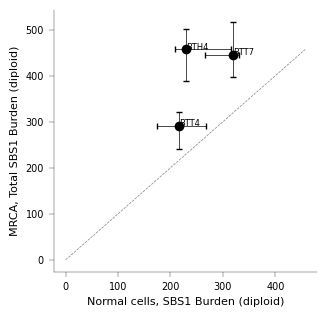

In [23]:

# Compute summary table for normal + trunk
summary_table_nt = (
    merged_cell_data2_sigs_sel
    .groupby(['sample_id_x', 'data_type_x'])['burden_diploid_corr_SBS1_merged_normal']
    .agg(
        count = 'count',
        median_value = 'median',
        Q1 = lambda x: x.quantile(0.25),
        Q3 = lambda x: x.quantile(0.75)
    )
    .reset_index()
)

# Separate normal and trunk
normal_df = summary_table_nt[summary_table_nt['data_type_x'] == 'scNormal']
trunk_df = summary_table_nt[summary_table_nt['data_type_x'] == 'trunk_cell']

# Merge side-by-side
plot_df_nt = pd.merge(
    normal_df,
    trunk_df,
    on='sample_id_x',
    suffixes=('_normal', '_trunk')
)

# Filter for sufficient data points
plot_df_nt = plot_df_nt[
    (plot_df_nt['count_normal'] > 5) &
    (plot_df_nt['count_trunk'] > 5)
].dropna(subset=['median_value_normal', 'median_value_trunk'])

# Compute asymmetric error bars
xerr = np.array([
    plot_df_nt['median_value_normal'] - plot_df_nt['Q1_normal'],  # lower
    plot_df_nt['Q3_normal'] - plot_df_nt['median_value_normal']   # upper
])

yerr = np.array([
    plot_df_nt['median_value_trunk'] - plot_df_nt['Q1_trunk'],    # lower
    plot_df_nt['Q3_trunk'] - plot_df_nt['median_value_trunk']     # upper
])

# Plot
plt.figure(figsize=(3.4, 3.4))

plt.errorbar(
    x=plot_df_nt['median_value_normal'],
    y=plot_df_nt['median_value_trunk'],
    xerr=xerr,
    yerr=yerr,
    fmt='o',
    color='k',
    ecolor='k',
    elinewidth=0.5,
    capsize=2
)

# Add sample labels
for _, row in plot_df_nt.iterrows():
    plt.text(
        row['median_value_normal'],
        row['median_value_trunk'],
        row['sample_id_x'],
        fontsize=6
    )

# Diagonal reference line
max_burden = max(plot_df_nt['median_value_normal'].max(), plot_df_nt['median_value_trunk'].max())
plt.plot([0, max_burden], [0, max_burden], color='gray', linestyle='--', linewidth=0.5)

plt.xlabel('Normal cells, SBS1 Burden (diploid)')
plt.ylabel('MRCA, Total SBS1 Burden (diploid)')

for _ax in plt.gcf().axes:
    nature_axes(_ax)
plt.savefig(
    figure5d,
    format='pdf',
    dpi=300,
    bbox_inches='tight',
    metadata={'Creator': 'Matplotlib'}
)
plt.show()
